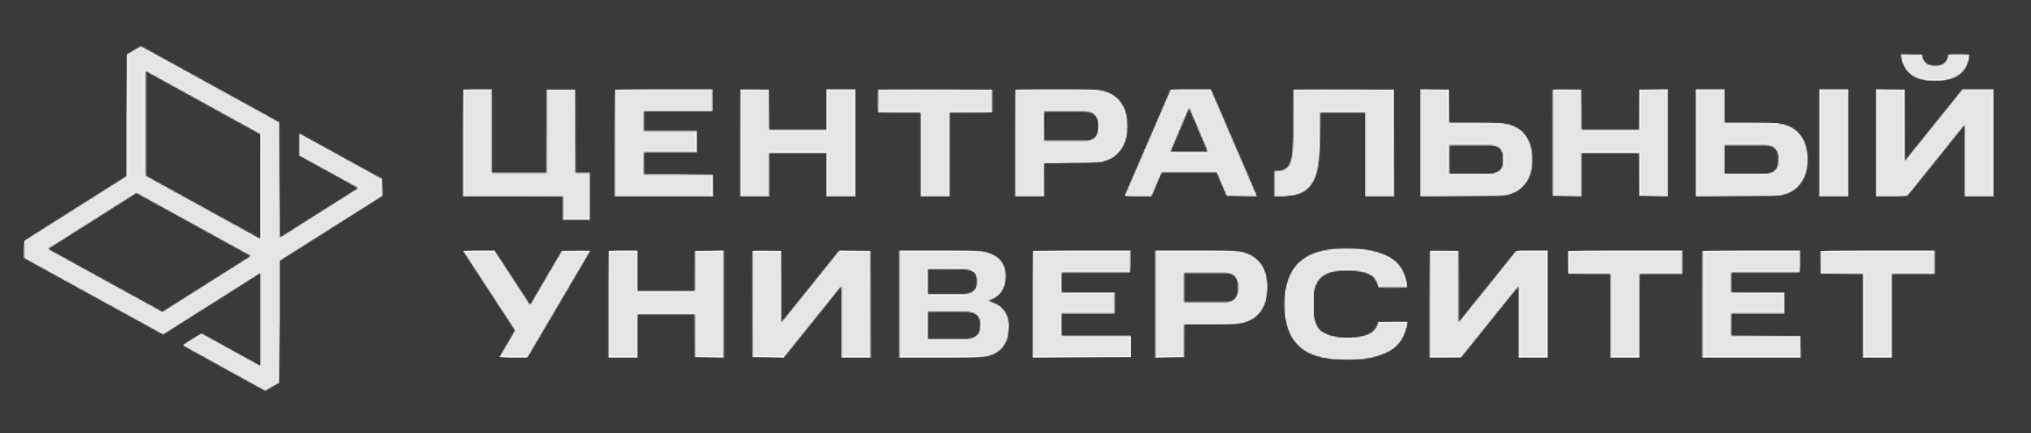


# Курс по Глубокому обучению

## Домашнее задание 1. Основы PyTorch (10 баллов)

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

## О задании

В данном задании вам предстоит попрактиковаться в работе с тензорами.

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи)

<font color='OrangeRed'>**Обратите внимание!**</font> В данном задании вам понадобится возможность работы с GPU. Мы предлагаем делать вам данное задание в Google Colab. При желании и наличии GPU на домашнем компьютере, можете развернуть необходимые драйверы и библиотеки для работы с вашим GPU и выполнять задание локально.

<font color='OrangeRed'>**Обратите внимание!**</font> Убедитесь, что при работе в Google Colab мы выбрали среду выполнения T4. Включить ее можно в менюшке, изображенной на картинках ниже:

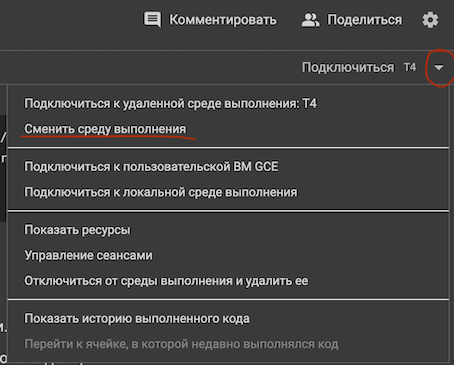

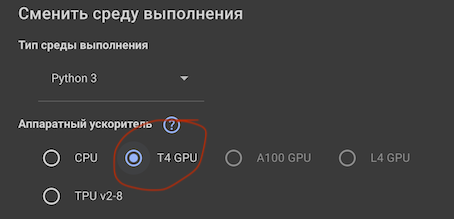

<font color='OrangeRed'>**Обратите внимание!**</font> Так как среда выполнения на T4 бесплатная, то Google Colab ограничивает ее использование по истечение некоторое времени сеанса. Проивзодите вычисления на GPU только в том случае, когда убедились, что аналогичный код на CPU отрабатывает! В крайнем случае, можете завести несколько гугл-аккаунтов, если произошла такая ситуация.

# Задание

<font color='OrangeRed'>**Важно!**</font> Если в задании не уточнено, то все создания и вычисления данных должны производиться на CPU

## <font color='DarkOrange'> **Задание 1 [3 балла]** </font>


<font color='DarkOrange'>**Задание [0.5 баллa]:**</font>

Создайте тензор (матрицу) 12$\times$12, заполненный случайными числами из равномерного распределения $U(-1, 1)$.

---

In [ ]:
import torch

torch.manual_seed(0)

# Матрица 12x12 из U(-1, 1)
X = None  # YOUR CODE HERE


<font color='DarkOrange'>**Задание [1 балл]:**</font>

Опишите функцию вычисления **фробениусовой нормы** матрицы (Frobenius norm) с помощью инструментария `torch`.

In [5]:
from IPython.display import display, Markdown

display(Markdown(r'$$\lVert X\rVert_F = \sqrt{\sum_{i=1}^{n}\sum_{j=1}^{m} X_{ij}^{2}}$$'))


$$\lVert X\rVert_F = \sqrt{\sum_{i=1}^{n}\sum_{j=1}^{m} X_{ij}^{2}}$$

**Нельзя использовать** встроенные функции `torch.norm` и `torch.linalg.norm`. В `torch` можно легко делать поэлементные операции и суммирование.

---

In [ ]:
def frobenius_norm(X):
    norm = None  # YOUR CODE HERE
    return norm


In [ ]:
print('Отлично!')


<font color='DarkOrange'>**Задание [1.5 баллa]:**</font>

Во многих задачах (например, в моделях непрерывного времени и дифференциальных уравнениях) встречается **матричная экспонента**.

Для матрицы $X \in \mathbb{R}^{n\times n}$ она определяется степенным рядом:

$$e^{X} = I + X + \frac{X^2}{2!} + \frac{X^3}{3!} + \dots$$

Ваше задание — написать функцию, которая приближённо вычисляет $e^X$ с помощью разложения Тейлора, ограничившись **12-й степенью**:

$$e^{X} \approx I + X + \frac{X^2}{2!} + \frac{X^3}{3!} + \dots + \frac{X^{12}}{12!}$$

**Нельзя использовать** `torch.matrix_exp` / `torch.linalg.matrix_exp`.

<font color='LightSteelBlue'>**Подсказка**</font> Удобно считать слагаемые рекуррентно:
$T_k = \frac{X^k}{k!}$, тогда $T_k = T_{k-1}\,X / k$.

---

In [ ]:
import math


def expm_taylor(X):
    I = torch.eye(X.shape[0], device=X.device, dtype=X.dtype)

    result = None  # YOUR CODE HERE
    term = None  # YOUR CODE HERE

    for k in range(1, 13):
    pass  # YOUR CODE HERE
    return result


In [ ]:
torch.manual_seed(0)
x = torch.randn(6, 6) / 3

approx = expm_taylor(x)
exact = torch.matrix_exp(x)

assert torch.max(torch.abs(approx - exact)) < 1e-3, 'Ошибка в вычислении матричной экспоненты (слишком большая погрешность)'
print('Отлично!')


## <font color='DarkOrange'> **Задание 2 [2 балла]** </font>


Библиотека Pytorch позволяет переносить вычисления на другие устройства, например, на видеокарту. Перенос вычислений с CPU на GPU при обучении нейронных сетей имеет несколько ключевых преимуществ, связанных с особенностями архитектуры графических процессоров и требований нейросетевых вычислений:

1. **Параллельная обработка данных**:
    * **GPU** предназначены для параллельных вычислений и способны обрабатывать тысячи потоков одновременно, что идеально подходит для операций таких как матричные умножения и свертки.
    * **CPU**, напротив, оптимизированы для последовательных операций и имеют ограниченное количество ядер (обычно 4–16). Хотя CPU может справляться с задачами параллельных вычислений, они не так эффективны для задач, требующих массового параллелизма.
2. **Высокая пропускная способность памяти**:
    * **GPU** имеют более высокую пропускную способность памяти, что позволяет быстрее передавать большие объемы данных.
3. **Оптимизация для векторных и матричных операций**:
    * **GPU**, в отличие от **CPU**, специально оптимизированы для выполнения векторных операций (перемножение матриц, сложение векторов и т.д.) за счет архитектуры с большим количеством ядер и оптимизированных инструкций для линейной алгебры.
4. **Эффективное использование тензорных операций**:
    * Нейронные сети активно используют тензорные вычисления, и **GPU** спроектированы для эффективной работы с тензорными операциями. Например, в современных **GPU** от NVIDIA используется технология Tensor Cores, специально созданная для ускорения операций с тензорами, что значительно ускоряет обучение глубоких моделей.

<font color='LightSteelBlue'>**Подсказка**</font>

В коде перенести данные из одного девайса на другое можно при помощи метода `to` (у данных или модели) или прямым указанием памяти как метода:

```
device = torch.device("cuda")
X = X.to(device)
X = X.cpu()
```

Подробнее про разные методы переноса можно посмотреть в первом семинаре или самостоятельно углубить знания в туториалах в интернете

<font color='DarkOrange'>**Задание [1 балл]:**</font>

Создайте три случайные матрицы $A$, $B$ и $C$ размера $8000 \times 8000$, указывая девайс **CPU**.

С помощью магической команды `%%time` оцените время выполнения следующих операций:

* $R_1 = A \odot B + C$, где $\odot$ — **поэлементное** умножение,
* $R_2 = A \otimes B + C$, где $\otimes$ — **обычное матричное** перемножение.

---

In [ ]:
n = 8000
A = None  # YOUR CODE HERE
B = None  # YOUR CODE HERE
C = None  # YOUR CODE HERE


In [ ]:
%%time

R1 = None  # YOUR CODE HERE


In [ ]:
%%time

R2 = None  # YOUR CODE HERE


<font color='DarkOrange'>**Задание [1 балл]:**</font>

Теперь перенесём $A$, $B$, $C$ на **GPU** и оценим скорость выполнения операций на видеокарте.

<font color='LightSteelBlue'>**Подсказка про замеры времени на GPU**</font>

CUDA-операции выполняются асинхронно, поэтому для честного времени стоит делать `torch.cuda.synchronize()` **до** и **после** вычисления внутри ячейки с `%%time`.

В выводах напишите, что вы заметили (ускорение, накладные расходы на перенос данных, «прогрев» первой операции и т.д.).

---

In [ ]:
A = A.cuda()
B = None  # YOUR CODE HERE
C = None  # YOUR CODE HERE


In [ ]:
%%time

R1 = None  # YOUR CODE HERE


In [ ]:
%%time

R2 = None  # YOUR CODE HERE


<font color='MediumOrchid'>**Ваши выводы тут:**</font>


## <font color='DarkOrange'> **Задание 3 [5 баллов]** </font>


Немного усложним предыдущее задание.

Представим, что мы работаем в финтехе и строим модель, которая по набору признаков пользователя оценивает, к какому из 3 классов относится событие:

1) обычное,
2) подозрительное,
3) мошенническое.

Один объект — это вектор из **256** признаков.

Ваша задача — собрать (не обучить) нейронную сеть, состоящую из **трёх линейных слоёв** и функций активации по следующей схеме:

```
X → Linear(256, 128) → ReLU → Linear(128, 32) → ReLU → Linear(32, 3) → SoftMax → Y
```


<font color='LightSteelBlue'>**Подсказка**</font>

Если хочется собрать модель «одной строчкой», можно использовать `torch.nn.Sequential`.

---

<font color='DarkOrange'>**Задание [0.5 баллa]:**</font>

Создайте случайную матрицу входных данных $X \in \mathbb{R}^{200000 \times 256}$ — 200 тысяч объектов с 256 признаками. Распределение — стандартное нормальное.

---

In [ ]:
X = None  # YOUR CODE HERE


<font color='DarkOrange'>**Задание [0.5 баллa]:**</font>

Соберите нейросеть по схеме выше.

* Линейные слои: `torch.nn.Linear`
* Активации: `ReLU` (между слоями) и `SoftMax` (в конце)

Можно реализовать сеть как набор слоёв + функция `infer`, а можно собрать всё в `nn.Sequential`.

---

In [ ]:
from torch import nn
model = nn.Sequential(
    nn.Identity(),  # YOUR CODE HERE
)


<font color='DarkOrange'>**Задание [2 баллa]:**</font>

Напишите функцию, которая будет применять данную нейросеть к входным данным, перекладывая данные и модель на определённое устройство.

Дополнительное требование (полезно в реальных задачах): реализуйте **инференс батчами** (mini-batch inference), чтобы не упираться в память.

---

In [ ]:
def infer(X, model, device='cpu', batch_size=8192):
    device = torch.device(device)  # YOUR CODE HERE
    return None  # YOUR CODE HERE


С помощью данной функции пропустим данные `X` через нейросеть и оценим время выполнения (на CPU):

---

In [ ]:
%%time

Y = infer(X, model)

assert Y.shape[0] == 200000 and Y.shape[1] == 3, 'Ошибка в model, несоответствие размеров выходных данных'
assert Y.device == torch.device('cpu'), "Выходные данные лежат не на CPU"
print('Отлично!')


<font color='DarkOrange'>**Задание [1 балл]:**</font>

Теперь перенесём входные данные $X$ и нейросеть на видеокарту и выясним, насколько быстрее произойдут вычисления.

В выводах опишите, насколько быстрее получилось сделать вычисления с помощью GPU по сравнению с CPU.

<font color='OrangeRed'>**Внимание!**</font> Если в Google Colab ловите OOM на GPU после нескольких запусков — можно «отключиться от среды и удалить её», а затем подключиться заново.

---

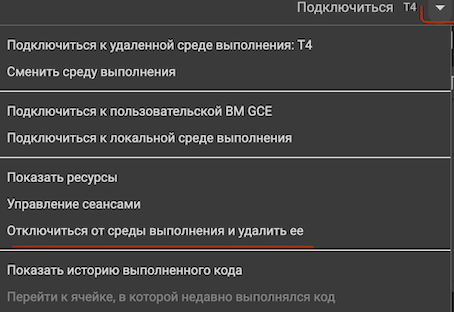

In [ ]:
%%time

# Для честного измерения на GPU (CUDA асинхронна):
# Раскомментируйте синхронизацию и запустите несколько раз, чтобы получить ожидаемый результат.
# torch.cuda.synchronize()
Y = infer(X, model, device='cuda')
# torch.cuda.synchronize()

assert Y.shape[0] == 200000 and Y.shape[1] == 3, 'Ошибка в model, несоответствие размеров выходных данных'
assert Y.device != torch.device('cpu'), "Выходные данные лежат не на GPU"
print('Отлично!')


<font color='MediumOrchid'>**Ваши выводы тут:**</font>


<font color='DarkOrange'>**Задание [1 балл]:**</font>

Ответьте на вопросы:

- почему GPU обычно быстрее CPU на операциях типа матричного умножения?
- в каких случаях GPU может **не дать ускорения** (или даже быть медленнее)?
- зачем при инференсе используют `model.eval()` и `torch.no_grad()`?
- зачем в конце многоклассовой модели часто ставят `SoftMax` и что означает параметр `dim`?
- почему важно обрабатывать данные батчами (mini-batches), когда данных много?

При необходимости используйте лекционный и семинарский материалы; а также можно гуглить и изучать релевантную информацию.

---

<font color='MediumOrchid'>**Ваши ответы тут:**</font>
